In [9]:
import cx_Oracle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 20, 10
import warnings
warnings.filterwarnings('ignore')



# Optional: Initialize Oracle Instant Client if needed (cx_Oracle auto-loads from PATH)
# cx_Oracle.init_oracle_client(lib_dir=r"C:\instantclient_19_11")

def get_connection():
    return cx_Oracle.connect(
        user="machine",
        password="machine",
        dsn="localhost/orcl"
    )

def run_query(query):
    conn = get_connection()
    df = pd.read_sql(query, conn)
    conn.close()
    return df

In [51]:
sql='select * from acc_ord_card_disp_client_dist aocdcd join loan_trans lt on lt.account_id= aocdcd.account_id'
df=run_query(sql)

In [52]:
df

,CARD_ID,DISP_ID,TYPE,ISSUED,ACCOUNT_ID,DISPOSITION_CLIENT_ID,DISPOSITION_TYPE,CLIENT_ID,BIRTH_NUMBER,DISTRICT_ID,...,BALANCE,K_SYMBOL,BANK,ACCOUNT,LOAN_ID,LOAN_DATE,LOAN_AMOUNT,DURATION,PAYMENTS,STATUS
0,1005,9285,classic,931107 00:00:00,7753,9593,OWNER,9593,685128,74,...,20188.0,None,None,None,6577,940311,51696,24,2154.00,A
1,1005,9285,classic,931107 00:00:00,7753,9593,OWNER,9593,685128,74,...,47266.0,None,None,None,6577,940311,51696,24,2154.00,A
2,874,7127,gold,971007 00:00:00,5891,7127,OWNER,7127,570929,3,...,33494.0,None,CD,51054984,6202,940418,65184,12,5432.00,A
3,1223,13231,junior,950502 00:00:00,11013,13539,OWNER,13539,780907,63,...,600.0,None,None,None,7240,930906,274740,60,4579.00,A
4,1223,13231,junior,950502 00:00:00,11013,13539,OWNER,13539,780907,63,...,600.0,None,None,None,7240,930906,274740,60,4579.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,1203,12893,classic,970926 00:00:00,10738,13201,OWNER,13201,370517,31,...,20112.3,SLUZBY,None,None,7192,941221,115992,36,3222.00,A
864,1203,12893,classic,970926 00:00:00,10738,13201,OWNER,13201,370517,31,...,20112.3,SLUZBY,None,None,7192,941221,115992,36,3222.00,A
865,1223,13231,junior,950502 00:00:00,11013,13539,OWNER,13539,780907,63,...,41112.9,SLUZBY,None,None,7240,930906,274740,60,4579.00,A
866,1223,13231,junior,950502 00:00:00,11013,13539,OWNER,13539,780907,63,...,41112.9,SLUZBY,None,None,7240,930906,274740,60,4579.00,A


In [13]:

df.shape

(868, 50)

In [14]:
df.columns

Index(['CARD_ID', 'DISP_ID', 'TYPE', 'ISSUED', 'ACCOUNT_ID',
       'DISPOSITION_CLIENT_ID', 'DISPOSITION_TYPE', 'CLIENT_ID',
       'BIRTH_NUMBER', 'DISTRICT_ID', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7',
       'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'ORDER_ID',
       'BANK_TO', 'ACCOUNT_TO', 'AMOUNT', 'K_SYMBOL', 'ACCOUNT_DATE',
       'ACCOUNT_DISTRICT_ID', 'FREQUENCY', 'TRANS_ID', 'ACCOUNT_ID', 'DATES',
       'TYPE', 'OPERATION', 'AMOUNT', 'BALANCE', 'K_SYMBOL', 'BANK', 'ACCOUNT',
       'LOAN_ID', 'LOAN_DATE', 'LOAN_AMOUNT', 'DURATION', 'PAYMENTS',
       'STATUS'],
      dtype='object')

In [18]:
print(df.isnull().sum())

CARD_ID                    0
DISP_ID                    0
TYPE                       0
ISSUED                     0
ACCOUNT_ID                 0
DISPOSITION_CLIENT_ID      0
DISPOSITION_TYPE           0
CLIENT_ID                  0
BIRTH_NUMBER               0
DISTRICT_ID                0
A1                         0
A2                         0
A3                         0
A4                         0
A5                         0
A6                         0
A7                         0
A8                         0
A9                         0
A10                        0
A11                        0
A12                        0
A13                        0
A14                        0
A15                        0
A16                        0
ORDER_ID                   0
BANK_TO                    0
ACCOUNT_TO                 0
AMOUNT                     0
K_SYMBOL                   0
ACCOUNT_DATE               0
ACCOUNT_DISTRICT_ID        0
FREQUENCY                  0
TRANS_ID      

In [42]:
pd.DataFrame(df)

,CARD_ID,DISP_ID,TYPE,ISSUED,ACCOUNT_ID,DISPOSITION_CLIENT_ID,DISPOSITION_TYPE,CLIENT_ID,BIRTH_NUMBER,DISTRICT_ID,...,BALANCE,K_SYMBOL,BANK,ACCOUNT,LOAN_ID,LOAN_DATE,LOAN_AMOUNT,DURATION,PAYMENTS,STATUS
0,1005,9285,classic,931107 00:00:00,7753,9593,OWNER,9593,685128,74,...,20188.0,None,None,None,6577,940311,51696,24,2154.00,A
1,1005,9285,classic,931107 00:00:00,7753,9593,OWNER,9593,685128,74,...,47266.0,None,None,None,6577,940311,51696,24,2154.00,A
2,874,7127,gold,971007 00:00:00,5891,7127,OWNER,7127,570929,3,...,33494.0,None,CD,51054984,6202,940418,65184,12,5432.00,A
3,1223,13231,junior,950502 00:00:00,11013,13539,OWNER,13539,780907,63,...,600.0,None,None,None,7240,930906,274740,60,4579.00,A
4,1223,13231,junior,950502 00:00:00,11013,13539,OWNER,13539,780907,63,...,600.0,None,None,None,7240,930906,274740,60,4579.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,1203,12893,classic,970926 00:00:00,10738,13201,OWNER,13201,370517,31,...,20112.3,SLUZBY,None,None,7192,941221,115992,36,3222.00,A
864,1203,12893,classic,970926 00:00:00,10738,13201,OWNER,13201,370517,31,...,20112.3,SLUZBY,None,None,7192,941221,115992,36,3222.00,A
865,1223,13231,junior,950502 00:00:00,11013,13539,OWNER,13539,780907,63,...,41112.9,SLUZBY,None,None,7240,930906,274740,60,4579.00,A
866,1223,13231,junior,950502 00:00:00,11013,13539,OWNER,13539,780907,63,...,41112.9,SLUZBY,None,None,7240,930906,274740,60,4579.00,A


In [43]:
display(df.STATUS.unique())

array(['A', 'B', 'C', 'D'], dtype=object)

In [30]:
display(df.STATUS.value_counts())

STATUS
A    648
B    168
C     51
D      1
Name: count, dtype: int64

In [59]:
df.STATUS=pd.DataFrame(df.STATUS.map({'A':0,'B':1,'C':2,'D':3}),columns=['STATUS'])


In [60]:
df.STATUS.unique()

[0, 1, 2, 3]
Categories (4, int64): [0, 1, 2, 3]

In [61]:
df.STATUS.value_counts()

STATUS
0    648
1    168
2     51
3      1
Name: count, dtype: int64

In [62]:
df.new_status.value_counts()

new_status
0    648
1    168
2     51
3      1
Name: count, dtype: int64

In [56]:
df['STATUS']=df['STATUS'].astype('category')

In [57]:
df['new_status']=df['STATUS'].cat.codes

In [58]:
df

,CARD_ID,DISP_ID,TYPE,ISSUED,ACCOUNT_ID,DISPOSITION_CLIENT_ID,DISPOSITION_TYPE,CLIENT_ID,BIRTH_NUMBER,DISTRICT_ID,...,K_SYMBOL,BANK,ACCOUNT,LOAN_ID,LOAN_DATE,LOAN_AMOUNT,DURATION,PAYMENTS,STATUS,new_status
0,1005,9285,classic,931107 00:00:00,7753,9593,OWNER,9593,685128,74,...,None,None,None,6577,940311,51696,24,2154.00,A,0
1,1005,9285,classic,931107 00:00:00,7753,9593,OWNER,9593,685128,74,...,None,None,None,6577,940311,51696,24,2154.00,A,0
2,874,7127,gold,971007 00:00:00,5891,7127,OWNER,7127,570929,3,...,None,CD,51054984,6202,940418,65184,12,5432.00,A,0
3,1223,13231,junior,950502 00:00:00,11013,13539,OWNER,13539,780907,63,...,None,None,None,7240,930906,274740,60,4579.00,A,0
4,1223,13231,junior,950502 00:00:00,11013,13539,OWNER,13539,780907,63,...,None,None,None,7240,930906,274740,60,4579.00,A,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,1203,12893,classic,970926 00:00:00,10738,13201,OWNER,13201,370517,31,...,SLUZBY,None,None,7192,941221,115992,36,3222.00,A,0
864,1203,12893,classic,970926 00:00:00,10738,13201,OWNER,13201,370517,31,...,SLUZBY,None,None,7192,941221,115992,36,3222.00,A,0
865,1223,13231,junior,950502 00:00:00,11013,13539,OWNER,13539,780907,63,...,SLUZBY,None,None,7240,930906,274740,60,4579.00,A,0
866,1223,13231,junior,950502 00:00:00,11013,13539,OWNER,13539,780907,63,...,SLUZBY,None,None,7240,930906,274740,60,4579.00,A,0


In [64]:
df=df.drop('new_status',axis=1)

In [65]:
df

,CARD_ID,DISP_ID,TYPE,ISSUED,ACCOUNT_ID,DISPOSITION_CLIENT_ID,DISPOSITION_TYPE,CLIENT_ID,BIRTH_NUMBER,DISTRICT_ID,...,BALANCE,K_SYMBOL,BANK,ACCOUNT,LOAN_ID,LOAN_DATE,LOAN_AMOUNT,DURATION,PAYMENTS,STATUS
0,1005,9285,classic,931107 00:00:00,7753,9593,OWNER,9593,685128,74,...,20188.0,None,None,None,6577,940311,51696,24,2154.00,0
1,1005,9285,classic,931107 00:00:00,7753,9593,OWNER,9593,685128,74,...,47266.0,None,None,None,6577,940311,51696,24,2154.00,0
2,874,7127,gold,971007 00:00:00,5891,7127,OWNER,7127,570929,3,...,33494.0,None,CD,51054984,6202,940418,65184,12,5432.00,0
3,1223,13231,junior,950502 00:00:00,11013,13539,OWNER,13539,780907,63,...,600.0,None,None,None,7240,930906,274740,60,4579.00,0
4,1223,13231,junior,950502 00:00:00,11013,13539,OWNER,13539,780907,63,...,600.0,None,None,None,7240,930906,274740,60,4579.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,1203,12893,classic,970926 00:00:00,10738,13201,OWNER,13201,370517,31,...,20112.3,SLUZBY,None,None,7192,941221,115992,36,3222.00,0
864,1203,12893,classic,970926 00:00:00,10738,13201,OWNER,13201,370517,31,...,20112.3,SLUZBY,None,None,7192,941221,115992,36,3222.00,0
865,1223,13231,junior,950502 00:00:00,11013,13539,OWNER,13539,780907,63,...,41112.9,SLUZBY,None,None,7240,930906,274740,60,4579.00,0
866,1223,13231,junior,950502 00:00:00,11013,13539,OWNER,13539,780907,63,...,41112.9,SLUZBY,None,None,7240,930906,274740,60,4579.00,0


In [67]:
df.columns

Index(['CARD_ID', 'DISP_ID', 'TYPE', 'ISSUED', 'ACCOUNT_ID',
       'DISPOSITION_CLIENT_ID', 'DISPOSITION_TYPE', 'CLIENT_ID',
       'BIRTH_NUMBER', 'DISTRICT_ID', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7',
       'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'ORDER_ID',
       'BANK_TO', 'ACCOUNT_TO', 'AMOUNT', 'K_SYMBOL', 'ACCOUNT_DATE',
       'ACCOUNT_DISTRICT_ID', 'FREQUENCY', 'TRANS_ID', 'ACCOUNT_ID', 'DATES',
       'TYPE', 'OPERATION', 'AMOUNT', 'BALANCE', 'K_SYMBOL', 'BANK', 'ACCOUNT',
       'LOAN_ID', 'LOAN_DATE', 'LOAN_AMOUNT', 'DURATION', 'PAYMENTS',
       'STATUS'],
      dtype='object')

In [70]:
x=df[['LOAN_AMOUNT','DURATION','PAYMENTS']].values
display(x)

array([['51696', '24', '2154.00'],
       ['51696', '24', '2154.00'],
       ['65184', '12', '5432.00'],
       ...,
       ['274740', '60', '4579.00'],
       ['274740', '60', '4579.00'],
       ['274740', '60', '4579.00']], shape=(868, 3), dtype=object)

In [71]:
y=df['STATUS'].values
y

[0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0]
Length: 868
Categories (4, int64): [0, 1, 2, 3]

In [73]:
# now we will do the min max scaler
from sklearn.preprocessing import MinMaxScaler
sc_x=MinMaxScaler()
x=sc_x.fit_transform(x)
display(x)

array([[0.11695884, 0.25      , 0.16005898],
       [0.11695884, 0.25      , 0.16005898],
       [0.15951687, 0.        , 0.69708388],
       ...,
       [0.82071864, 1.        , 0.55733945],
       [0.82071864, 1.        , 0.55733945],
       [0.82071864, 1.        , 0.55733945]], shape=(868, 3))

In [74]:
# train and split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=143)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(607, 3)
(261, 3)
(607,)
(261,)


In [ ]:
# to check KNeighbors from 1 to 15 and check the accuracy

In [83]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
accuracy=[]
for i in range(1,15):
    KNN=KNeighborsClassifier(n_neighbors=i)
    KNN=KNN.fit(x_train,y_train)
    y_pred=KNN.predict(x_train)
    acc=accuracy_score(y_train,y_pred)
    accuracy.append(acc)

    

In [84]:
accuracy

[1.0,
 0.9983525535420099,
 0.9967051070840197,
 0.9967051070840197,
 0.9967051070840197,
 0.9917627677100495,
 0.9917627677100495,
 0.9917627677100495,
 0.9917627677100495,
 0.9917627677100495,
 0.9917627677100495,
 0.9917627677100495,
 0.9917627677100495,
 0.9917627677100495]

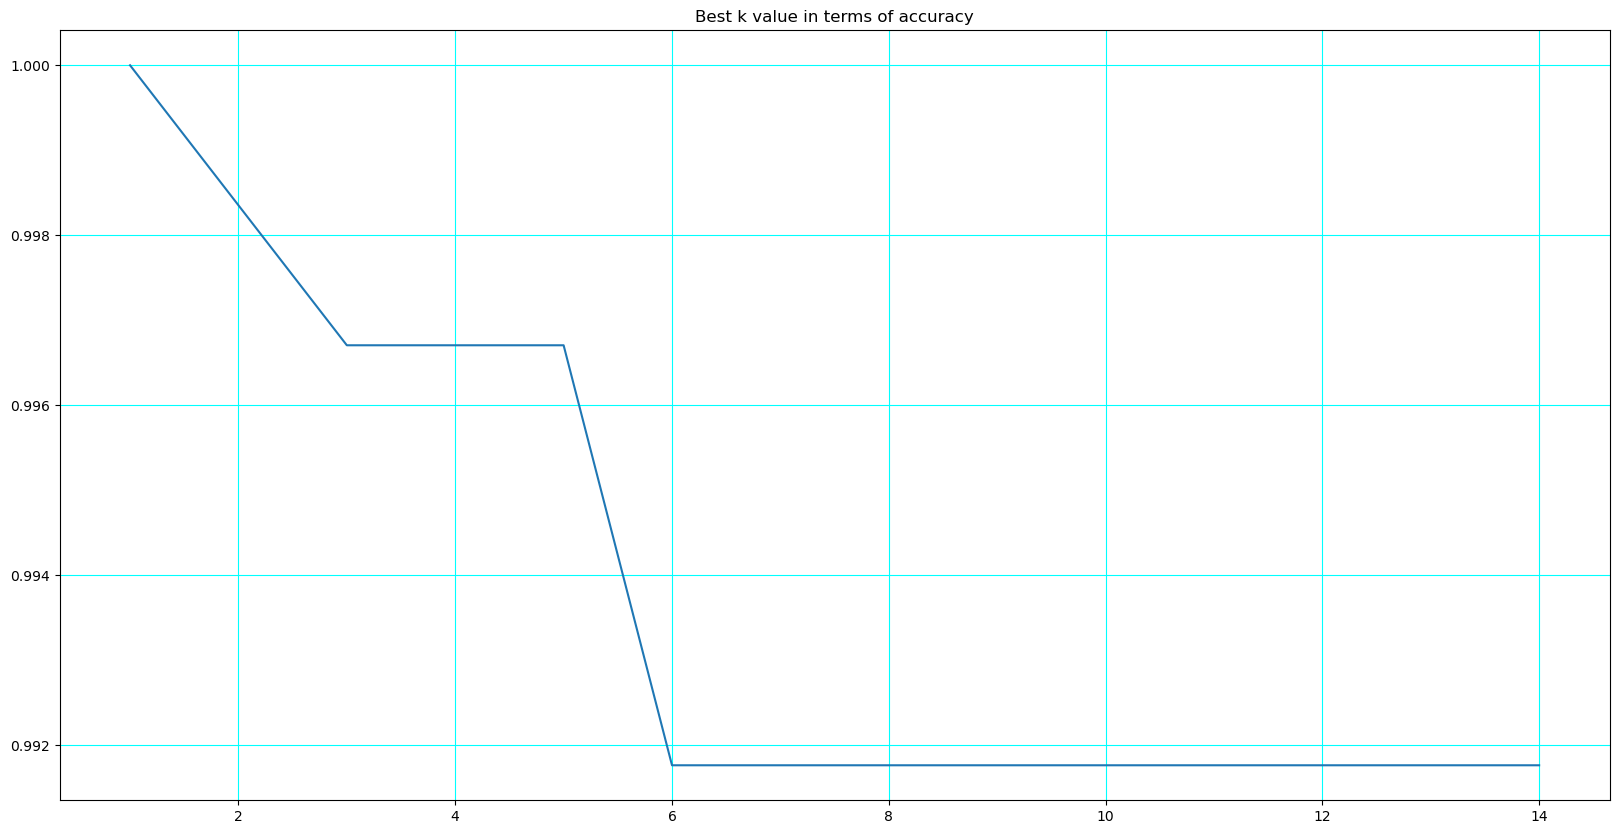

In [85]:
plt.plot(range(1,15),accuracy)
plt.title('Best k value in terms of accuracy')
plt.grid(True,color='cyan')
plt.show()

In [86]:
knn=KNeighborsClassifier(n_neighbors=1)
knn=knn.fit(x_train,y_train)


In [89]:
y_pred=knn.predict(x_test)
print(accuracy_score(y_test,y_pred))

1.0


In [90]:
y_pred_all=knn.predict(x)
print(accuracy_score(y,y_pred_all))

1.0


In [91]:
y_pred_all

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 2,
       0, 0, 0, 1, 1, 1, 1, 2, 0, 0, 0, 0, 0, 0, 0,

In [95]:
from sklearn.metrics import confusion_matrix,classification_report
print('confusion matrix: \n',confusion_matrix(y,y_pred_all))
print('Classification Report:',classification_report(y,y_pred_all,zero_division=0))
    

confusion matrix: 
 [[648   0   0   0]
 [  0 168   0   0]
 [  0   0  51   0]
 [  0   0   0   1]]
Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00       648
           1       1.00      1.00      1.00       168
           2       1.00      1.00      1.00        51
           3       1.00      1.00      1.00         1

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



In [105]:
prediction = knn.predict([[189300,60,3155]])
print(prediction)

[2]


In [97]:
import pickle

In [99]:
import os
os.chdir('D:\\topmentor\\Cohort 127_ML_ Day 48\\MY SQL Project Python\\Data Set\\')

In [101]:
pickle.dump(knn,open('kneighbors_model_loan_status.pkl','wb'))

In [102]:
model=pickle.load(open('kneighbors_model_loan_status.pkl','rb'))
model

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [114]:
from sklearn.tree import DecisionTreeClassifier
DT=DecisionTreeClassifier(criterion='entropy')
DT=DT.fit(x_train,y_train)
DT_pred_test=DT.predict(x_test)
print('Accuracy score on test data:',accuracy_score(y_test,DT_pred_test))
print('Confusion Matrix on test data :',confusion_matrix(y_test,DT_pred_test))

DT_pred_all=DT.predict(x)
print('Accuracy score on test data:',accuracy_score(y,DT_pred_all))
print('Confusion Matrix on test data :',confusion_matrix(y,DT_pred_all))

Accuracy score on test data: 1.0
Confusion Matrix on test data : [[198   0   0]
 [  0  49   0]
 [  0   0  14]]
Accuracy score on test data: 1.0
Confusion Matrix on test data : [[648   0   0   0]
 [  0 168   0   0]
 [  0   0  51   0]
 [  0   0   0   1]]


In [117]:
# criterion='gini
from sklearn.tree import DecisionTreeClassifier
DT=DecisionTreeClassifier(criterion='gini')
DT=DT.fit(x_train,y_train)
DT_pred_test=DT.predict(x_test)
print('Accuracy score on test data:',accuracy_score(y_test,DT_pred_test))
print('Confusion Matrix on test data :',confusion_matrix(y_test,DT_pred_test))

DT_pred_all=DT.predict(x)
print('Accuracy score on test data:',accuracy_score(y,DT_pred_all))
print('Confusion Matrix on test data :',confusion_matrix(y,DT_pred_all))

Accuracy score on test data: 1.0
Confusion Matrix on test data : [[198   0   0]
 [  0  49   0]
 [  0   0  14]]
Accuracy score on test data: 1.0
Confusion Matrix on test data : [[648   0   0   0]
 [  0 168   0   0]
 [  0   0  51   0]
 [  0   0   0   1]]
